In [46]:
%matplotlib inline

import random
import math
import time
import os
from os.path import join
import sys
import pandas as pd
pd.set_option('display.max_columns', 500)
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy
import bz2

from nltk.tokenize import sent_tokenize

from nltk.tokenize import TweetTokenizer
from nltk.tokenize import RegexpTokenizer
tweet_tokenize = TweetTokenizer().tokenize
regex_tokenize = RegexpTokenizer(r'\w+').tokenize

import matplotlib.colors as mcolors
import pickle

from tqdm.notebook import tqdm_notebook

#import statsmodels as sm
import statsmodels.api as sm
import scipy.stats as st
from statsmodels.tools.tools import add_constant
from statsmodels.regression.linear_model import OLS
from sklearn import linear_model
from sklearn import preprocessing

emotion_columns = ['admiration', 'amusement', 'anger', 'curiosity', 'desire', 'embarrassment', 
                   'fear', 'gratitude', 'joy', 'love', 'optimism', 'pride', 'remorse', 'sadness', 'surprise'
            ]

dimensions = emotion_columns
dimensions_redux = emotion_columns
dimensions_names = emotion_columns
dimensions_names_redux = emotion_columns
dims2name = {}

for dim in emotion_columns:
    if dim not in dims2name:
        dims2name[dim] = dim

def ci(x, confidence=0.95):
    avg = np.mean(x)
    low, high = st.t.interval(confidence, len(x)-1, loc=avg, scale=st.sem(x))
    return (avg, high-avg)
    
#dimension-dependent weights
def standardized_dimension_score(x,mu,std):
    zscore = (x-mu)/std
    if zscore >= 0:
        return 1/(1+zscore)
    else:
        zscore = -zscore
        return 2 - (1/(1+zscore))

In [47]:
positive_emotions = ["admiration", "amusement", "desire", "gratitude", "joy", "love", "optimism", "pride"]
negative_emotions = ["anger", "embarrassment", "fear", "remorse", "sadness"]
ambiguous_emotions = ["curiosity", "surprise"]

In [48]:
D = pd.read_csv("../data/paragraph_turns_ekman.csv")

In [49]:
columns_to_move = ['problem_solution', 'call_to_action', 'intention', 'execution']
D = D[[col for col in D.columns if col not in columns_to_move] + columns_to_move]

In [50]:
D.columns

Index(['sentence', 'collectiveAction', 'racialJustice',
       'collectiveActionMulti', 'episode_id', 'sentence_length', 'speaker',
       'newSpeaker', 'mfcc1_sma3Mean', 'mfcc2_sma3Mean', 'mfcc3_sma3Mean',
       'mfcc4_sma3Mean', 'F0semitoneFrom27_5Hz_sma3nzMean',
       'F1frequency_sma3nzMean', 'startTime', 'endTime', 'duration',
       'turnCount', 'streak', 'streak_length', 'gratitude', 'excitement',
       'joy', 'neutral', 'approval', 'admiration', 'relief', 'caring',
       'optimism', 'realization', 'surprise', 'pride', 'desire', 'love',
       'annoyance', 'amusement', 'confusion', 'sadness', 'curiosity', 'fear',
       'disapproval', 'nervousness', 'disgust', 'disappointment', 'anger',
       'grief', 'remorse', 'embarrassment', 'ekman', 'problem_solution',
       'call_to_action', 'intention', 'execution'],
      dtype='object')

In [51]:
for column in emotion_columns:
    D[f'{column}_weighted'] = D[column].copy()

In [52]:
D['number_of_words'] = D['sentence'].apply(lambda x: len(str(x).split()))
D['log_number_of_words'] = D['number_of_words'].apply(lambda x: np.log(x) if x > 0 else 0)

THRESHOLD

In [53]:
thresholds = {
    'admiration': 0.25,
    'amusement': 0.45,
    'anger': 0.15,
    'curiosity': 0.25,
    'desire': 0.25,
    'embarrassment': 0.10,
    'fear': 0.40,
    'gratitude': 0.45,
    'joy': 0.40,
    'love': 0.25,
    'optimism': 0.20,
    'pride': 0.10,
    'remorse': 0.10,
    'sadness': 0.40,
    'surprise': 0.15,
}

for emotion, threshold in thresholds.items():
    D[emotion] = (D[emotion] >= threshold).astype(int)

In [54]:
df = D[['collectiveAction'] + ['problem_solution'] + ['call_to_action'] + ['intention'] + ['execution'] + emotion_columns + [f'{col}_weighted' for col in emotion_columns] + ['log_number_of_words']]

In [55]:
df.head(1)

,collectiveAction,problem_solution,call_to_action,intention,execution,admiration,amusement,anger,curiosity,desire,embarrassment,fear,gratitude,joy,love,optimism,pride,remorse,sadness,surprise,admiration_weighted,amusement_weighted,anger_weighted,curiosity_weighted,desire_weighted,embarrassment_weighted,fear_weighted,gratitude_weighted,joy_weighted,love_weighted,optimism_weighted,pride_weighted,remorse_weighted,sadness_weighted,surprise_weighted,log_number_of_words
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.128012,0.00166,0.001449,0.001404,0.002748,0.000511,0.000956,0.077492,0.028698,0.004947,0.007183,0.002663,0.000443,0.00151,0.001327,4.744932


delta = collective action

++++++++++++admiration
avg. delta : 0.026468818929215963 count delta: 14961
avg. nodelta : 0.06515733645469128 count nodelta: 329771
OR = 0.3900855818887353
#dim-delta=396, #nodim-delta=14565, #dim-nodelta=21487, #nodim-nodelta=308284
++++++++++++amusement
avg. delta : 0.0005347236147316356 count delta: 14961
avg. nodelta : 0.006465092442937675 count nodelta: 329771
OR = 0.08221859387055049
#dim-delta=8, #nodim-delta=14953, #dim-nodelta=2132, #nodim-nodelta=327639
++++++++++++anger
avg. delta : 0.008689258739389078 count delta: 14961
avg. nodelta : 0.010789305305803118 count nodelta: 329771
OR = 0.8036523849802016
#dim-delta=130, #nodim-delta=14831, #dim-nodelta=3558, #nodim-nodelta=326213
++++++++++++curiosity
avg. delta : 0.036762248512799946 count delta: 14961
avg. nodelta : 0.09376506727395678 count nodelta: 329771
OR = 0.368865723520767
#dim-delta=550, #nodim-delta=14411, #dim-nodelta=30921, #nodim-nodelta=298850
++++++++++++desire
avg. delta : 0.01443753759775416 count delta: 149

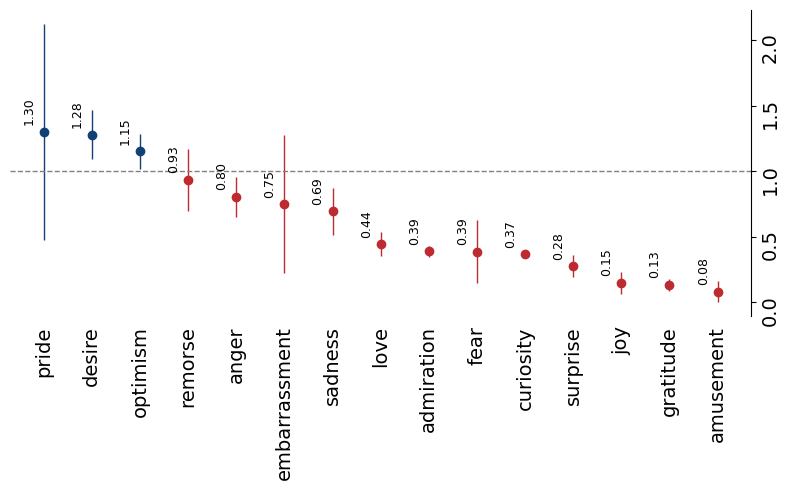

In [56]:
import numpy as np
import matplotlib.pyplot as plt

all_dims = dimensions_names_redux 

def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

df_no_delta = df[df['collectiveAction'] == 0].dropna()
df_delta = df[df['collectiveAction'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio.pdf')
plt.show()

In [57]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio.csv', index=False)
print(f"Results saved to '../plots/odds_ratio.csv'")

Results saved to '../plots/odds_ratio.csv'


In [58]:
results_df.columns

Index(['emotion', 'odds_ratio', 'lower_ci', 'upper_ci'], dtype='object')

In [59]:
# Map each emotion to a category
def get_category(emotion):
    if emotion in positive_emotions:
        return "positive"
    elif emotion in negative_emotions:
        return "negative"
    elif emotion in ambiguous_emotions:
        return "ambiguous"
    else:
        return "unknown"

# Add a category column
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_simple.csv', index=False)
print(f"Results saved!")

Results saved!


++++++++++++admiration
avg. delta : 0.01901743264659271 count delta: 10096
avg. nodelta : 0.06481968467230065 count nodelta: 334636
OR = 0.27969135297212
#dim-delta=192, #nodim-delta=9904, #dim-nodelta=21691, #nodim-nodelta=312945
++++++++++++amusement
avg. delta : 0.0006933438985736926 count delta: 10096
avg. nodelta : 0.006374090056060914 count nodelta: 334636
OR = 0.10815699951630674
#dim-delta=7, #nodim-delta=10089, #dim-nodelta=2133, #nodim-nodelta=332503
++++++++++++anger
avg. delta : 0.01059825673534073 count delta: 10096
avg. nodelta : 0.01070117978938309 count nodelta: 334636
OR = 0.9902790584303445
#dim-delta=107, #nodim-delta=9989, #dim-nodelta=3580, #nodim-nodelta=331056
++++++++++++curiosity
avg. delta : 0.024068938193343898 count delta: 10096
avg. nodelta : 0.09331930814377414 count nodelta: 334636
OR = 0.2396186669805069
#dim-delta=243, #nodim-delta=9853, #dim-nodelta=31228, #nodim-nodelta=303408
++++++++++++desire
avg. delta : 0.006339144215530904 count delta: 10096
avg

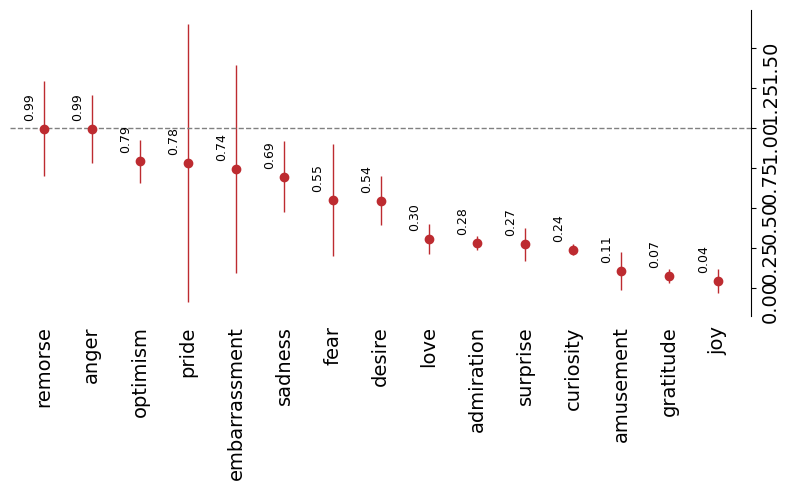

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# Helper function for confidence intervals
def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

# Filter your DataFrame
df_no_delta = df[df['problem_solution'] == 0].dropna()
df_delta = df[df['problem_solution'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio_problem_solution.pdf')
plt.show()

In [61]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio_problem_solution.csv', index=False)
print(f"Results saved to '../plots/odds_ratio_problem_solution.csv'")

Results saved to '../plots/odds_ratio_problem_solution.csv'


In [62]:
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_problem_solution_simple.csv', index=False)
print(f"Results saved!")

Results saved!


In [63]:
odds_problem_solution = pd.DataFrame({
    'Emotion': all_dims, 
    'Odds Ratio': y_oddsratio, 
    'Lower CI': [or_val - ci for or_val, ci in zip(y_oddsratio, y_ci_OR)], 
    'Upper CI': [or_val + ci for or_val, ci in zip(y_oddsratio, y_ci_OR)]
})

odds_problem_solution.head()

,Emotion,Odds Ratio,Lower CI,Upper CI
0,admiration,0.279691,0.236541,0.322842
1,amusement,0.108157,-0.010896,0.227210
2,anger,0.990279,0.779083,1.201475
3,curiosity,0.239619,0.206951,0.272287
4,desire,0.543270,0.390495,0.696045


++++++++++++admiration
avg. delta : 0.01812688821752266 count delta: 1655
avg. nodelta : 0.06369707091993926 count nodelta: 343077
OR = 0.27137185881889125
#dim-delta=30, #nodim-delta=1625, #dim-nodelta=21853, #nodim-nodelta=321224
++++++++++++amusement
avg. delta : 0.0 count delta: 1655
avg. nodelta : 0.006237666762854986 count nodelta: 343077
OR = 0.00015931651445670134
#dim-delta=0, #nodim-delta=1655, #dim-nodelta=2140, #nodim-nodelta=340937
++++++++++++anger
avg. delta : 0.01027190332326284 count delta: 1655
avg. nodelta : 0.010700221816093763 count nodelta: 343077
OR = 0.959555623407435
#dim-delta=17, #nodim-delta=1638, #dim-nodelta=3671, #nodim-nodelta=339406
++++++++++++curiosity
avg. delta : 0.006042296072507553 count delta: 1655
avg. nodelta : 0.0917024458066265 count nodelta: 343077
OR = 0.06021176022535356
#dim-delta=10, #nodim-delta=1645, #dim-nodelta=31460, #nodim-nodelta=311617
++++++++++++desire
avg. delta : 0.009667673716012085 count delta: 1655
avg. nodelta : 0.0114609

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_99575/855220156.py:68: RuntimeWarning: overflow encountered in exp
  ci_OR_upper = np.exp(log_OR + ci_log_OR)


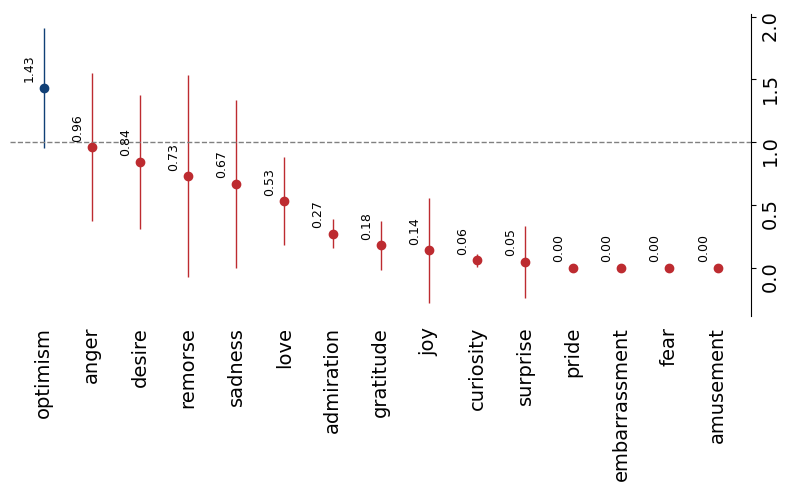

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Helper function for confidence intervals
def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

# Filter your DataFrame
df_no_delta = df[df['call_to_action'] == 0].dropna()
df_delta = df[df['call_to_action'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio_call_to_action.pdf')
plt.show()

In [65]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio_call_to_action.csv', index=False)
print(f"Results saved to '../plots/odds_ratio_call_to_action.csv'")

Results saved to '../plots/odds_ratio_call_to_action.csv'


In [66]:
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_call_to_action_simple.csv', index=False)
print(f"Results saved!")

Results saved!


In [67]:
odds_call_to_action = pd.DataFrame({
    'Emotion': all_dims, 
    'Odds Ratio': y_oddsratio, 
    'Lower CI': [or_val - ci for or_val, ci in zip(y_oddsratio, y_ci_OR)], 
    'Upper CI': [or_val + ci for or_val, ci in zip(y_oddsratio, y_ci_OR)]
})

++++++++++++admiration
avg. delta : 0.03188405797101449 count delta: 2760
avg. nodelta : 0.06373328810545893 count nodelta: 341972
OR = 0.48381516389107526
#dim-delta=88, #nodim-delta=2672, #dim-nodelta=21795, #nodim-nodelta=320177
++++++++++++amusement
avg. delta : 0.0 count delta: 2760
avg. nodelta : 0.006257822277847309 count nodelta: 341972
OR = 0.00015880015880015877
#dim-delta=0, #nodim-delta=2760, #dim-nodelta=2140, #nodim-nodelta=339832
++++++++++++anger
avg. delta : 0.002898550724637681 count delta: 2760
avg. nodelta : 0.010761114945083224 count nodelta: 341972
OR = 0.26723015672396355
#dim-delta=8, #nodim-delta=2752, #dim-nodelta=3680, #nodim-nodelta=338292
++++++++++++curiosity
avg. delta : 0.10434782608695652 count delta: 2760
avg. nodelta : 0.09118582807949188 count nodelta: 341972
OR = 1.161159195217459
#dim-delta=288, #nodim-delta=2472, #dim-nodelta=31182, #nodim-nodelta=310790
++++++++++++desire
avg. delta : 0.04456521739130435 count delta: 2760
avg. nodelta : 0.0111851

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_99575/1804142765.py:68: RuntimeWarning: overflow encountered in exp
  ci_OR_upper = np.exp(log_OR + ci_log_OR)


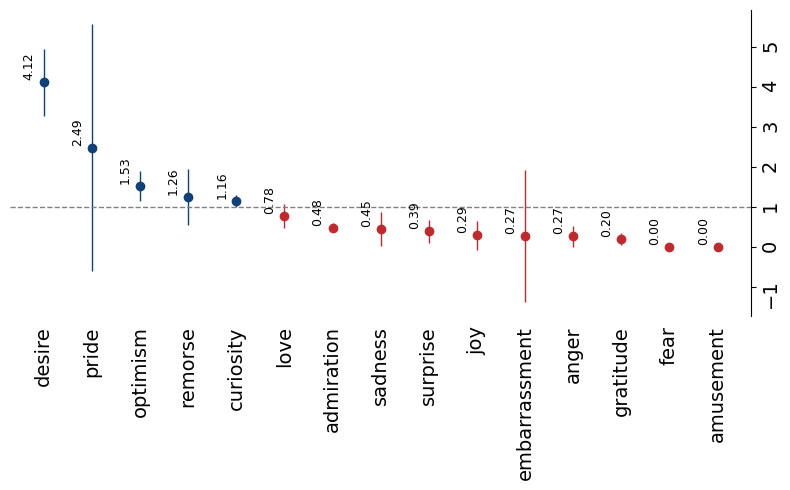

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# Helper function for confidence intervals
def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

# Filter your DataFrame
df_no_delta = df[df['intention'] == 0].dropna()
df_delta = df[df['intention'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio_intention.pdf')
plt.show()

In [69]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio_intention.csv', index=False)
print(f"Results saved to '../plots/odds_ratio_intention.csv'")

Results saved to '../plots/odds_ratio_intention.csv'


In [70]:
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_intention_simple.csv', index=False)
print(f"Results saved!")

Results saved!


In [71]:
odds_intention = pd.DataFrame({
    'Emotion': all_dims, 
    'Odds Ratio': y_oddsratio, 
    'Lower CI': [or_val - ci for or_val, ci in zip(y_oddsratio, y_ci_OR)], 
    'Upper CI': [or_val + ci for or_val, ci in zip(y_oddsratio, y_ci_OR)]
})

++++++++++++admiration
avg. delta : 0.035926055109870944 count delta: 2867
avg. nodelta : 0.06370935895748321 count nodelta: 341865
OR = 0.5476544653215486
#dim-delta=103, #nodim-delta=2764, #dim-nodelta=21779, #nodim-nodelta=320086
++++++++++++amusement
avg. delta : 0.0003487966515521451 count delta: 2867
avg. nodelta : 0.006256855776402966 count nodelta: 341865
OR = 0.05541684732448624
#dim-delta=1, #nodim-delta=2866, #dim-nodelta=2139, #nodim-nodelta=339726
++++++++++++anger
avg. delta : 0.0010463899546564353 count delta: 2867
avg. nodelta : 0.010779108712503474 count nodelta: 341865
OR = 0.09612993943436703
#dim-delta=3, #nodim-delta=2864, #dim-nodelta=3685, #nodim-nodelta=338180
++++++++++++curiosity
avg. delta : 0.008371119637251482 count delta: 2867
avg. nodelta : 0.09198660289880509 count nodelta: 341865
OR = 0.0833301297044116
#dim-delta=24, #nodim-delta=2843, #dim-nodelta=31447, #nodim-nodelta=310418
++++++++++++desire
avg. delta : 0.007324729682595047 count delta: 2867
avg. 

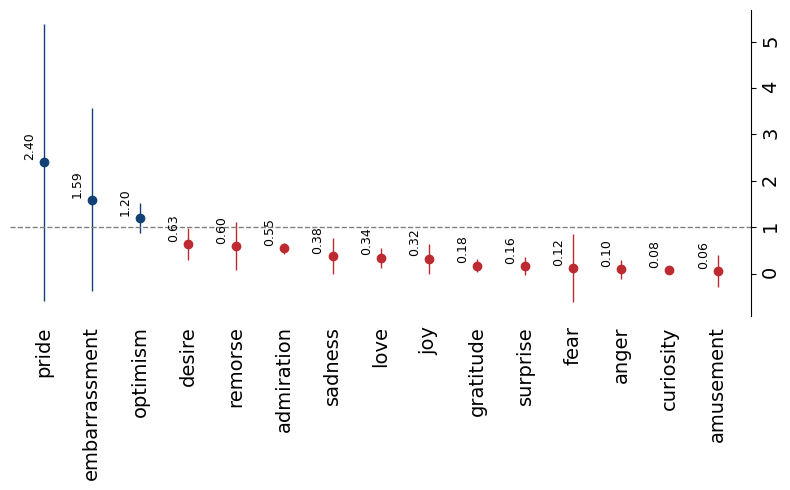

In [72]:
import numpy as np
import matplotlib.pyplot as plt

# Helper function for confidence intervals
def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

# Filter your DataFrame
df_no_delta = df[df['execution'] == 0].dropna()
df_delta = df[df['execution'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio_execution.pdf')
plt.show()

In [73]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio_execution.csv', index=False)
print(f"Results saved to '../plots/odds_ratio_execution.csv'")

Results saved to '../plots/odds_ratio_execution.csv'


In [74]:
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_execution_simple.csv', index=False)
print(f"Results saved!")

Results saved!


In [75]:
odds_execution = pd.DataFrame({
    'Emotion': all_dims, 
    'Odds Ratio': y_oddsratio, 
    'Lower CI': [or_val - ci for or_val, ci in zip(y_oddsratio, y_ci_OR)], 
    'Upper CI': [or_val + ci for or_val, ci in zip(y_oddsratio, y_ci_OR)]
})

Matrix of significant odds ratios

In [76]:
odds_dfs = {
    'Problem-Solution': odds_problem_solution,
    'Call-to-Action': odds_call_to_action,
    'Intention': odds_intention,
    'Execution': odds_execution
}
odds_matrix = pd.DataFrame({'Emotion': odds_problem_solution['Emotion']})

for level, df in odds_dfs.items():
    df_filtered = df[(df['Lower CI'] > 1) | (df['Upper CI'] < 1)]  # Keep only significant odds ratios
    df_filtered = df_filtered[['Emotion', 'Odds Ratio']].rename(columns={'Odds Ratio': level})
    odds_matrix = odds_matrix.merge(df_filtered, on='Emotion', how='left')

odds_matrix
odds_matrix.set_index('Emotion', inplace=True)
odds_matrix

,Problem-Solution,Call-to-Action,Intention,Execution
Emotion,,,,
admiration,0.279691,0.271372,0.483815,0.547654
amusement,0.108157,NaN,NaN,0.055417
anger,NaN,NaN,0.267230,0.096130
curiosity,0.239619,0.060212,1.161159,0.083330
desire,0.543270,NaN,4.123529,0.634981
embarrassment,NaN,NaN,NaN,NaN
fear,0.548276,NaN,NaN,0.121244
gratitude,0.072934,0.177681,0.197462,0.175298
joy,0.044534,0.139310,0.292312,0.321693


In [77]:
min_value = odds_matrix.min().min()
max_value = odds_matrix.max().max()

print(f"Smallest value: {min_value}")
print(f"Largest value: {max_value}")

Smallest value: 0.044533919378036434
Largest value: 4.123529263051447


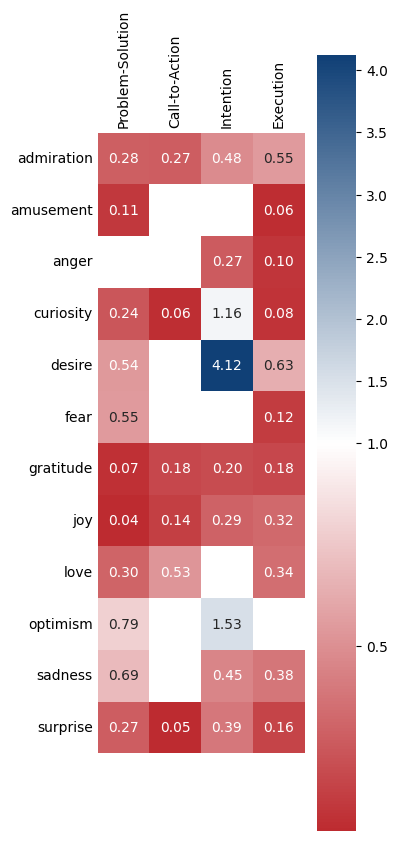

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Filter out rows where all values are NaN
odds_matrix_significant = odds_matrix.dropna(how='all')

# Check if 'Emotion' is the index, if not, set it as the index
if 'Emotion' in odds_matrix_significant.columns:
    odds_matrix_significant = odds_matrix_significant.set_index('Emotion', drop=True)

# Ensure all data is numeric
odds_matrix_significant = odds_matrix_significant.apply(pd.to_numeric, errors='coerce')

# Define a custom diverging colormap with 1.00 centered at white
colors = ["#BD2B30", "white", "#104076"]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# Use a symmetric scale to center at 1.0
divnorm = mcolors.TwoSlopeNorm(vcenter=1.0)

# Create the heatmap
plt.figure(figsize=(4, 10))
ax = sns.heatmap(
    odds_matrix_significant, 
    annot=True, 
    cmap=custom_cmap, 
    norm=divnorm,  # Ensure white is at 1.00
    fmt=".2f", 
    square=True,
    linewidths=0,  # Remove lines between rows and columns
    #cbar_kws={'label': 'Odds Ratio'},
    xticklabels=True,  # Show x-axis labels (levels of participation)
    yticklabels=True  # Show y-axis labels (emotions)
)

# # Set ticks and labels on colormap from 0.25 to 4 with steps of 0.25
# cbar = ax.collections[0].colorbar
# cbar.set_ticks(np.arange(0.25, 4.25, 0.25))
# cbar.set_ticklabels(np.arange(0.25, 4.25, 0.25).round(2))  # Set tick labels

# Move xticks to top
ax.xaxis.set_ticks_position('top')

# Remove tick marks but keep the labels
ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# Ensure x and y axis labels are visible and aligned correctly
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)  # Make sure x labels are not rotated
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated



# Remove title and x/y labels
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')

# Show the plot
plt.tight_layout()
plt.savefig('../plots/heatmap.pdf', orientation='landscape')

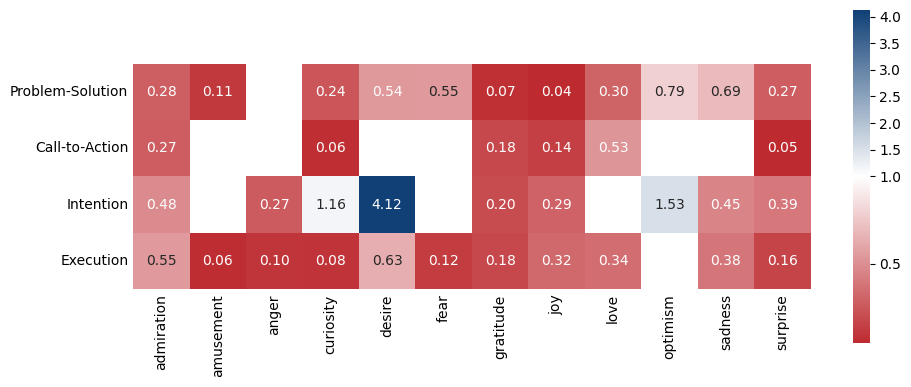

In [79]:
# Transpose the data to switch x and y axes
odds_matrix_significant_transposed = odds_matrix_significant.transpose()

colors = ["#BD2B30", "white", "#104076"]  # Swap blue and red

# Create the heatmap with transposed data
plt.figure(figsize=(10, 4))  # Adjust figure size if needed
ax = sns.heatmap(
    odds_matrix_significant_transposed, 
    annot=True, 
    cmap=custom_cmap, 
    norm=divnorm,  # Ensure white is at 1.00
    fmt=".2f", 
    square=True,
    linewidths=0,  # Remove lines between rows and columns
    xticklabels=True,  # Show x-axis labels (levels of participation)
    yticklabels=True  # Show y-axis labels (emotions)
)

# Move yticks to the left (default)
ax.yaxis.set_ticks_position('left')

# Remove tick marks but keep the labels
ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# Ensure x and y axis labels are visible and aligned correctly
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)  # Make sure x labels are not rotated
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated

# Remove title and x/y labels
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')

# Show the plot
plt.tight_layout()
plt.savefig('../plots/heatmap.pdf', orientation='landscape')


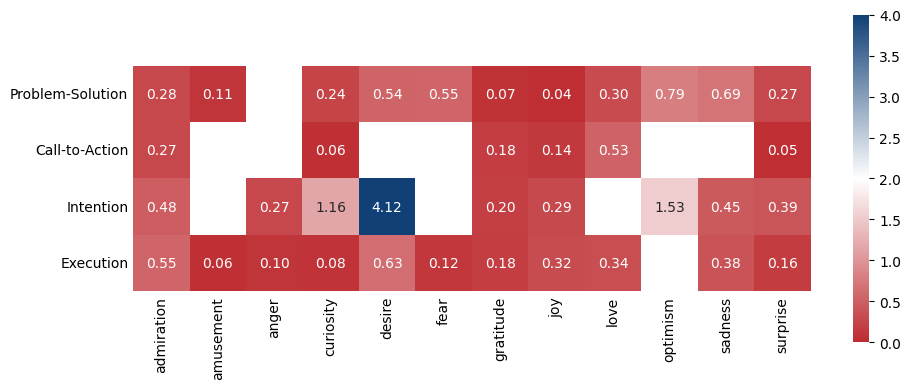

In [80]:
# Define a custom diverging colormap with 1.00 centered at white, but switch blue and red
colors = ["#BD2B30", "white", "#104076"]  # Swap blue and red
custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# Use a symmetric scale to center at 2.0, while keeping 1.0 as white
divnorm = mcolors.TwoSlopeNorm(vmin=0, vcenter=2.0, vmax=4)

# Create the heatmap with transposed data and updated colormap
plt.figure(figsize=(10, 4))  # Adjust figure size if needed
ax = sns.heatmap(
    odds_matrix_significant_transposed, 
    annot=True, 
    cmap=custom_cmap, 
    norm=divnorm,  # Set center of colormap to 2.0
    fmt=".2f", 
    square=True,
    linewidths=0,  # Remove lines between rows and columns
    xticklabels=True,  # Show x-axis labels (levels of participation)
    yticklabels=True  # Show y-axis labels (emotions)
)

# Move yticks to the left (default)
ax.yaxis.set_ticks_position('left')

# Remove tick marks but keep the labels
ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# Ensure x and y axis labels are visible and aligned correctly
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)  # Make sure x labels are not rotated
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated

# Remove title and x/y labels
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')

# Show the plot
plt.tight_layout()
plt.savefig('../plots/heatmap.pdf', orientation='landscape')

In [81]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors

# # Filter out rows where all values are NaN
# odds_matrix_significant = odds_matrix.dropna(how='all')

# # Check if 'Emotion' is the index, if not, set it as the index
# if 'Emotion' in odds_matrix_significant.columns:
#     odds_matrix_significant = odds_matrix_significant.set_index('Emotion', drop=True)

# # Ensure all data is numeric
# odds_matrix_significant = odds_matrix_significant.apply(pd.to_numeric, errors='coerce')

# # Define a custom colormap
# colors = ["#BD2B30", "white", "#104076"]  # Red for -3, white for 1, blue for 5
# custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# # Define the custom normalization with the vmin and vmax parameters
# norm = mcolors.Normalize(vmin=0, vmax=5)

# # Create the heatmap
# plt.figure(figsize=(10, 8))
# ax = sns.heatmap(
#     odds_matrix_significant, 
#     annot=True, 
#     cmap=custom_cmap,  # Apply the custom colormap
#     norm=norm,  # Use the custom normalization
#     fmt=".2f", 
#     linewidths=0,  # Remove lines between rows and columns
#     cbar_kws={'label': 'Odds Ratio'},
#     xticklabels=True,  # Show x-axis labels (levels of participation)
#     yticklabels=True  # Show y-axis labels (emotions)
# )

# # Move xticks to top
# ax.xaxis.set_ticks_position('top')

# # Remove tick marks but keep the labels
# ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
# ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# # Ensure x and y axis labels are visible and aligned correctly
# ax.set_xticklabels(ax.get_xticklabels(), rotation=0)  # Make sure x labels are not rotated
# ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated

# # Remove title and x/y labels
# ax.set_title('')
# ax.set_xlabel('')
# ax.set_ylabel('')

# # Show the plot
# plt.tight_layout()
# plt.show()

In [82]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# import numpy as np

# # Filter out rows where all values are NaN
# odds_matrix_significant = odds_matrix.dropna(how='all')

# # Check if 'Emotion' is the index, if not, set it as the index
# if 'Emotion' in odds_matrix_significant.columns:
#     odds_matrix_significant = odds_matrix_significant.set_index('Emotion', drop=True)

# # Ensure all data is numeric
# odds_matrix_significant = odds_matrix_significant.apply(pd.to_numeric, errors='coerce')

# # Define a custom colormap
# colors = ["#BD2B30", "white", "#104076"]  # Red for the smallest value, white for 1, blue for the largest value
# custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# # Get the smallest and largest values in the matrix
# vmin = odds_matrix_significant.min().min()  # smallest value in the dataframe
# vmax = odds_matrix_significant.max().max()  # largest value in the dataframe

# # Define custom boundaries and normalization
# boundaries = [vmin, 1, vmax]  # Define custom bins for color mapping
# norm = mcolors.BoundaryNorm(boundaries, custom_cmap.N)

# # Create the heatmap
# plt.figure(figsize=(10, 8))
# ax = sns.heatmap(
#     odds_matrix_significant, 
#     annot=True, 
#     cmap=custom_cmap,  # Apply the custom colormap
#     norm=norm,  # Use the custom normalization with boundaries
#     fmt=".2f", 
#     linewidths=0,  # Remove lines between rows and columns
#     cbar_kws={'label': 'Odds Ratio'},
#     xticklabels=True,  # Show x-axis labels (levels of participation)
#     yticklabels=True  # Show y-axis labels (emotions)
# )

# # Move xticks to top
# ax.xaxis.set_ticks_position('top')

# # Remove tick marks but keep the labels
# ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
# ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# # Ensure x and y axis labels are visible and aligned correctly
# ax.set_xticklabels(ax.get_xticklabels(), rotation=0)  # Make sure x labels are not rotated
# ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated

# # Remove title and x/y labels
# ax.set_title('')
# ax.set_xlabel('')
# ax.set_ylabel('')

# # Show the plot
# plt.tight_layout()
# plt.show()
